# Step 5 — Empirical Tests: Epic Giveaway → Steam Engagement

Implements and compares the staggered DiD strategies described in the writeup.

**Input:**  `../raw_data/steamcharts/all_monthly.csv` (Step 4 output)
**Output:** figure PDFs/PNGs and `summary_stats.csv` in `../output/`

**Packages:** `pyfixest 0.40`, `scipy 1.15`, `statsmodels 0.14`, `numpy`, `pandas`, `matplotlib`.

## Sections
1. Data loading and preparation
2. Descriptive statistics
3. TWFE event study (`pyfixest.feols` with `i(k_clip, ref=-1)`)
4. Pre-trend F-test (Wald test on pre-period coefficients)
5. Estimator comparison: TWFE vs. LP-DiD vs. stacked DiD (Cengiz et al.)
6. Separated specification (first-giveaway vs. repeat-giveaway effect)
7. Cohort-level ATTs (Callaway–Sant'Anna style, not-yet-treated controls)
8. Popularity-stratified analysis (high vs. low pre-treatment traffic)
9. Randomization placebo (200 permutations of treatment dates)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import chi2 as chi2_dist, norm as norm_dist
import pyfixest as pf
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_DIR   = Path('../raw_data')
OUTPUT_DIR = Path('../output')
OUTPUT_DIR.mkdir(exist_ok=True)

PANEL_CSV = DATA_DIR / 'steamcharts' / 'all_monthly.csv'
K_MIN, K_MAX = -12, 12
K_REF        = -1

## 1. Data loading and preparation

In [2]:
df = pd.read_csv(PANEL_CSV, parse_dates=['month', 'first_giveaway_date'])

# Outcome
df['ln_avg'] = np.log1p(df['avg_players'])

# Relative event time k
df['k'] = (
    (df['month'].dt.year  - df['first_giveaway_date'].dt.year)  * 12 +
    (df['month'].dt.month - df['first_giveaway_date'].dt.month)
)

# ── Event-study sample: full-window games only, hard-trimmed (no clipping) ──
# Clipping (k.clip) would stuff all obs outside the window into the boundary
# bins, biasing k=K_MIN and k=K_MAX estimates. Instead we drop rows outside
# the window entirely. We also restrict to games that have observations for
# every month in [K_MIN, K_MAX] so the composition of the k-bin sample is
# constant across the pre-period (prevents spurious pre-trends from changing
# sample composition).
_game_months  = df.groupby('appid')['month'].apply(set)
_game_treat   = (df.groupby('appid')['first_giveaway_date']
                   .first()
                   .apply(lambda d: d.replace(day=1)))
_full_window_games = {
    appid
    for appid, treat_mo in _game_treat.items()
    if {treat_mo + pd.DateOffset(months=k) for k in range(K_MIN, K_MAX + 1)}
       .issubset(_game_months[appid])
}
print(f'Games with full [{K_MIN},{K_MAX}] window: {len(_full_window_games)}')

# Calendar-time identifiers in YYYYMM format (required by pyfixest.did)
df['t_ym'] = df['month'].dt.year * 100 + df['month'].dt.month
df['g_ym'] = (df['first_giveaway_date'].dt.year * 100
              + df['first_giveaway_date'].dt.month)

# Treatment cohort (year-quarter of first giveaway)
df['cohort_q'] = df['first_giveaway_date'].dt.to_period('Q').astype(str)

# Sequential month index (0 = Jul 2012, the earliest panel month)
# Required for pyfixest.lpdid which computes period differences directly
_base_y, _base_m = 2012, 7
df['t_seq'] = (df['month'].dt.year - _base_y) * 12 + (df['month'].dt.month - _base_m)
df['g_seq']  = ((df['first_giveaway_date'].dt.year - _base_y) * 12
                + (df['first_giveaway_date'].dt.month - _base_m))

# k_clip: used in all TWFE regressions (standard event-study boundary approach).
# Obs with k < K_MIN are coded as k=K_MIN; obs with k > K_MAX as k=K_MAX.
# The full unbalanced panel (df) is required for TWFE — a perfectly balanced
# ±K window panel causes t_ym = g_ym + k identically, collapsing game + time
# FEs into perfect collinearity with the k dummies and exploding SEs.
df['k_clip'] = df['k'].clip(K_MIN, K_MAX)

# df_es: diagnostic/descriptive use ONLY (not for TWFE regressions).
# Restricted to the 336 games with a full [K_MIN, K_MAX] window, trimmed to
# that window. Useful for coverage checks and the CS cohort-ATT estimator
# which does its own within-cohort comparisons.
df_es = (
    df[df['appid'].isin(_full_window_games) & df['k'].between(K_MIN, K_MAX)]
    .copy()
)
print(f'Event-study panel (df_es, coverage check): {len(df_es):,} rows | {df_es["appid"].nunique()} games')

print(f"Panel  : {len(df):,} rows | {df['appid'].nunique()} games | "
      f"{df['month'].nunique()} calendar months")
print(f"Date   : {df['month'].min().date()} → {df['month'].max().date()}")
print(f"k range: {df['k'].min()} → {df['k'].max()}")
print(f"Cohorts: {df['g_ym'].nunique()} distinct treatment months")
print(f"repeat_event_it = 1: {df['repeat_event_it'].sum():,} game-months "
      f"({df[df['repeat_event_it']==1]['appid'].nunique()} games)")
df.head(3)

Games with full [-12,12] window: 336
Event-study panel (df_es, coverage check): 8,400 rows | 336 games
Panel  : 38,642 rows | 446 games | 164 calendar months
Date   : 2012-07-01 → 2026-02-01
k range: -150 → 85
Cohorts: 80 distinct treatment months
repeat_event_it = 1: 838 game-months (63 games)


,appid,steam_name,epic_name,month,avg_players,peak_players,first_giveaway_date,all_giveaway_dates,repeat_event_it,ln_avg,k,t_ym,g_ym,cohort_q,t_seq,g_seq,k_clip
0,7800,Stubbs the Zombie in Rebel Without a Pulse,Stubbs the Zombie in Rebel Without a Pulse,2012-07-01,1.02,4,2021-10-14,2021-10-14,0,0.703098,-111,201207,202110,2021Q4,0,111,-12
1,7800,Stubbs the Zombie in Rebel Without a Pulse,Stubbs the Zombie in Rebel Without a Pulse,2012-08-01,0.41,4,2021-10-14,2021-10-14,0,0.343590,-110,201208,202110,2021Q4,1,111,-12
2,7800,Stubbs the Zombie in Rebel Without a Pulse,Stubbs the Zombie in Rebel Without a Pulse,2012-09-01,0.17,4,2021-10-14,2021-10-14,0,0.157004,-109,201209,202110,2021Q4,2,111,-12


## 2. Descriptive statistics

Panel: **446 games × up to 165 calendar months** (July 2012 – February 2026), 38,642 game-month observations. Each game's series starts from its Steam release date, so coverage is unbalanced (median 88 months per game). All 446 games are eventually treated; identification rests on staggered timing variation.

Outcome: `ln_avg = ln(avg_players + 1)` — log of monthly average concurrent players, with +1 offset to handle zero-player months and compress the heavy right tail of AAA titles.

**Sample restrictions applied upstream:**

- 13 games with no SteamCharts data (HTTP 500) excluded
- 4 games with duplicate Steam App IDs (matched from two Epic names) collapsed
- 8 Epic titles confirmed absent from Steam (5 EGS-exclusives + 3 placeholders) dropped

**Event-study sample (`df_es`):** 336 games observed for every month in the full `[−12, +12]` window. Out-of-window observations are dropped (not clipped to boundary bins) to avoid biasing the boundary-period estimates.


In [3]:
# Pre-treatment median players per game
pre = df[df['k'] < 0].groupby('appid')['avg_players'].median().rename('pre_median')
print("Pre-treatment median avg_players:")
print(pre.describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(1))
print(f"\nPre-median < 10  : {(pre < 10).sum()} games")
print(f"Pre-median 10–49 : {((pre >= 10) & (pre < 50)).sum()} games")
print(f"Pre-median ≥ 50  : {(pre >= 50).sum()} games")

# ── Panel-level summary ──────────────────────────────────────────────────────
print(f"\n{'─'*55}")
print(f"Panel structure")
print(f"{'─'*55}")
print(f"  Total observations     : {len(df):,}")
print(f"  Games                  : {df['appid'].nunique()}")
print(f"  Calendar months        : {df['month'].nunique()}"
      f" ({df['month'].min().strftime('%b %Y')} – {df['month'].max().strftime('%b %Y')})")
game_obs = df.groupby('appid').size()
print(f"  Obs per game (mean/med): {game_obs.mean():.0f} / {game_obs.median():.0f}")
print(f"  Games < 24 months      : {(game_obs < 24).sum()}")
print(f"  Distinct treatment months : {df['g_ym'].nunique()}")

Pre-treatment median avg_players:
count      429.0
mean      1340.9
std       5690.8
min          0.1
10%          3.1
25%         11.8
50%         59.2
75%        379.0
90%       1814.3
99%      21992.0
max      63364.2
Name: pre_median, dtype: float64

Pre-median < 10  : 101 games
Pre-median 10–49 : 101 games
Pre-median ≥ 50  : 227 games

───────────────────────────────────────────────────────
Panel structure
───────────────────────────────────────────────────────
  Total observations     : 38,642
  Games                  : 446
  Calendar months        : 164 (Jul 2012 – Feb 2026)
  Obs per game (mean/med): 87 / 88
  Games < 24 months      : 27
  Distinct treatment months : 80


Table 1: Summary Statistics
Note: Game–month panel, 445 games, Jul 2012 – Feb 2026.
      N for game-month rows = 38,642 observations.
      N for 'months per game' = 445 games.

                                              N      Mean         SD   Min    P25  Median     P75         Max
Variable                                                                                                     
Avg. concurrent Steam players (monthly)  38,642  1,583.86   7,443.96  0.00  12.77   65.15  394.91  270,553.06
Peak concurrent Steam players (monthly)  38,642  3,214.08  14,861.15  0.00  38.00  171.00  974.00  527,652.00
ln(avg players + 1)  [outcome variable]  38,642      4.43       2.36  0.00   2.62    4.19    5.98       12.51
In post-window of repeat giveaway (0/1)  38,642      0.02       0.15  0.00   0.00    0.00    0.00        1.00
Months observed per game                    446      86.6       41.1     1     53      88     117         163

Saved summary_stats.csv


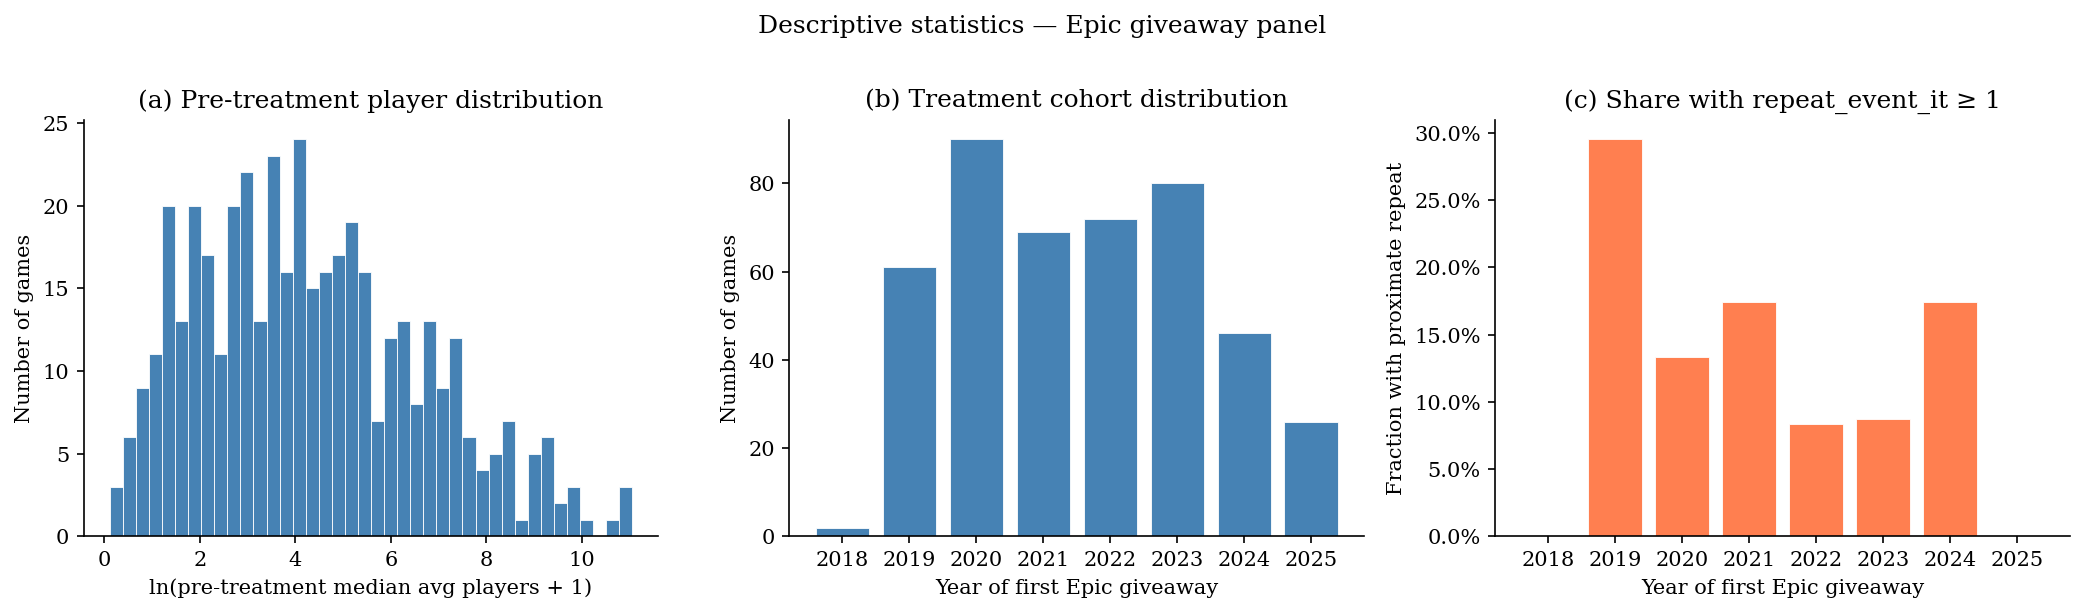

Saved fig_descriptives


In [4]:
# ── Summary Statistics Table (A6 requirement) ─────────────────────────────
# Game-month level observations
game_obs = df.groupby('appid').size()

var_specs = [
    ('avg_players',      'Avg. concurrent Steam players (monthly)'),
    ('peak_players',     'Peak concurrent Steam players (monthly)'),
    ('ln_avg',           'ln(avg players + 1)  [outcome variable]'),
    ('repeat_event_it',  'In post-window of repeat giveaway (0/1)'),
]

rows = []
for col, label in var_specs:
    s = df[col].dropna()
    rows.append({
        'Variable'  : label,
        'N'         : f'{len(s):,}',
        'Mean'      : f'{s.mean():,.2f}',
        'SD'        : f'{s.std():,.2f}',
        'Min'       : f'{s.min():,.2f}',
        'P25'       : f'{s.quantile(0.25):,.2f}',
        'Median'    : f'{s.median():,.2f}',
        'P75'       : f'{s.quantile(0.75):,.2f}',
        'Max'       : f'{s.max():,.2f}',
    })

# Game-level: months of coverage
rows.append({
    'Variable'  : 'Months observed per game',
    'N'         : f'{len(game_obs):,}',
    'Mean'      : f'{game_obs.mean():.1f}',
    'SD'        : f'{game_obs.std():.1f}',
    'Min'       : f'{game_obs.min()}',
    'P25'       : f'{game_obs.quantile(0.25):.0f}',
    'Median'    : f'{game_obs.median():.0f}',
    'P75'       : f'{game_obs.quantile(0.75):.0f}',
    'Max'       : f'{game_obs.max()}',
})

stats_tbl = pd.DataFrame(rows).set_index('Variable')

print("Table 1: Summary Statistics")
print(f"Note: Game–month panel, 445 games, Jul 2012 – Feb 2026.")
print(f"      N for game-month rows = {len(df):,} observations.")
print(f"      N for 'months per game' = 445 games.")
print()
print(stats_tbl.to_string())

# Save as CSV for easy import into LaTeX
stats_tbl.to_csv(OUTPUT_DIR / 'summary_stats.csv')
print('\nSaved summary_stats.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Pre-treatment player distribution
ax = axes[0]
ax.hist(np.log1p(pre.values), bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('ln(pre-treatment median avg players + 1)')
ax.set_ylabel('Number of games')
ax.set_title('(a) Pre-treatment player distribution')

# (b) Treatment cohort distribution by year
ax = axes[1]
cohort_year = (
    df.drop_duplicates('appid')['first_giveaway_date']
    .dt.year.value_counts().sort_index()
)
ax.bar(cohort_year.index, cohort_year.values,
       color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Year of first Epic giveaway')
ax.set_ylabel('Number of games')
ax.set_title('(b) Treatment cohort distribution')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# (c) Share of games with a proximate repeat giveaway, by cohort year
ax = axes[2]
game_meta = df.drop_duplicates('appid').set_index('appid')
repeat_appids = set(df[df['repeat_event_it'] == 1]['appid'].unique())
by_yr = (
    game_meta.groupby(game_meta['first_giveaway_date'].dt.year)
    .apply(lambda g: g.index.isin(repeat_appids).mean())
)
ax.bar(by_yr.index, by_yr.values, color='coral', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Year of first Epic giveaway')
ax.set_ylabel('Fraction with proximate repeat')
ax.set_title('(c) Share with repeat_event_it ≥ 1')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle('Descriptive statistics — Epic giveaway panel', fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_descriptives.pdf', bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'fig_descriptives.png', bbox_inches='tight')
plt.show()
print('Saved fig_descriptives')

### Outcome variable — distribution and raw event-time profile

Pooled specification:

$$\ln(y_{it}+1) = \alpha_i + \gamma_t
  + \sum_{k=-12,\,k\neq-1}^{12} \theta_k \cdot \mathbf{1}[\tilde{k}_{it}=k]
  + \varepsilon_{it}$$

where $\tilde{k}_{it} = \text{clip}(k_{it},\,-12,\,12)$ bins the pre- and post-window endpoints. Standard errors clustered by game. Estimated with `pyfixest.feols` (HDFE).

The figure below shows (a) the raw pre/post distribution of $\ln(\text{avg\_players}+1)$ and (b) the unconditional event-time mean profile — both *before* partialling out fixed effects.


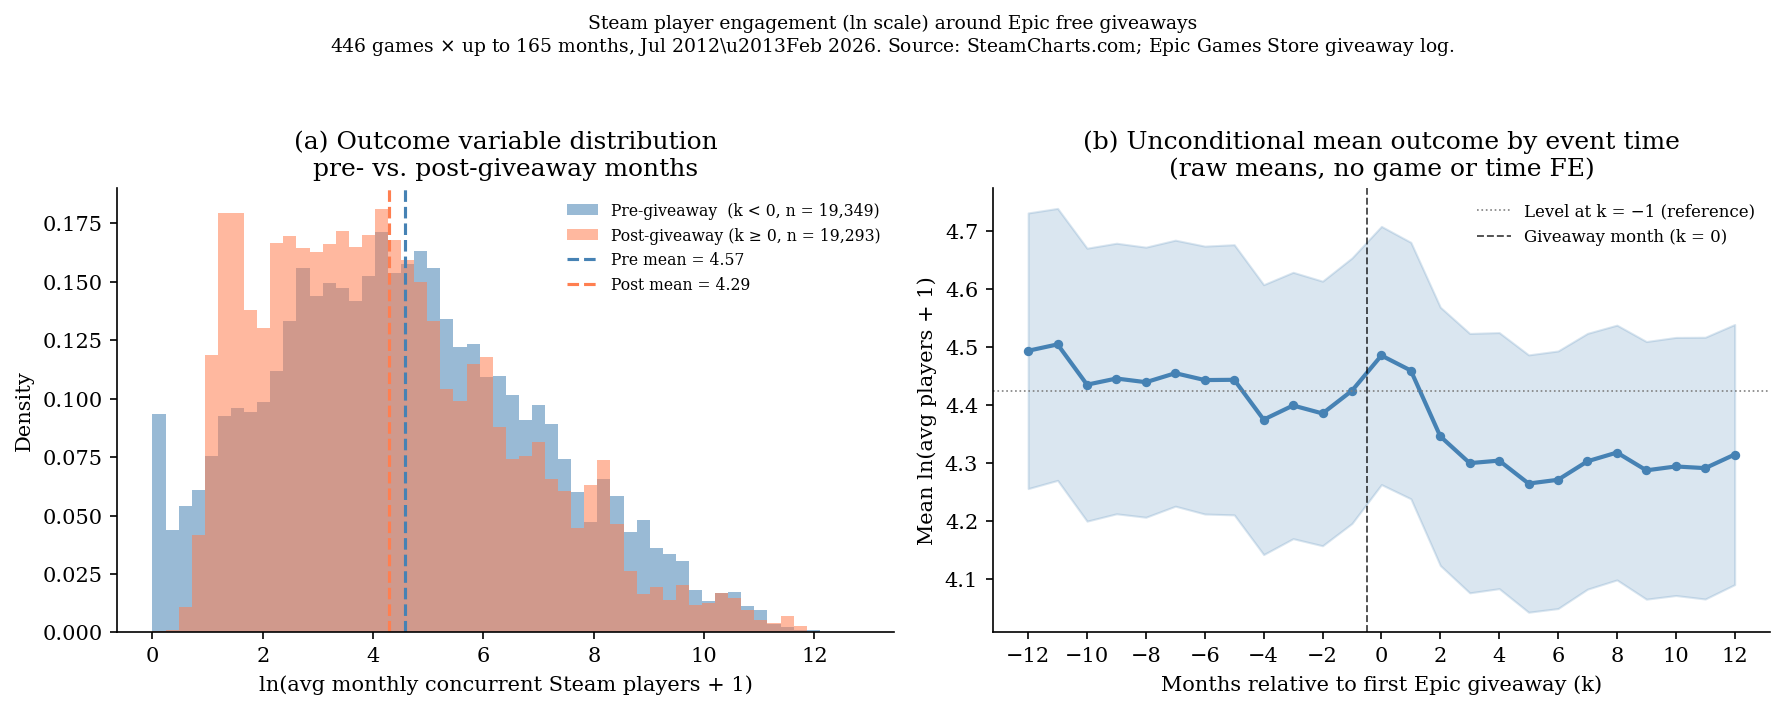

Saved fig_outcome_histogram


In [5]:
# ── Figure 1 (A6): Outcome variable distribution + raw event-time profile ──
pre_vals  = df[df['k'] < 0]['ln_avg'].dropna().values
post_vals = df[df['k'] >= 0]['ln_avg'].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: pre vs. post distribution
ax = axes[0]
bins = np.linspace(0, df['ln_avg'].max() + 0.3, 55)
ax.hist(pre_vals,  bins=bins, alpha=0.55, color='steelblue', edgecolor='none',
        density=True,
        label=f'Pre-giveaway  (k < 0, n = {len(pre_vals):,})')
ax.hist(post_vals, bins=bins, alpha=0.55, color='coral', edgecolor='none',
        density=True,
        label=f'Post-giveaway (k ≥ 0, n = {len(post_vals):,})')
ax.axvline(pre_vals.mean(),  color='steelblue', linewidth=1.5, linestyle='--',
           label=f'Pre mean = {pre_vals.mean():.2f}')
ax.axvline(post_vals.mean(), color='coral',     linewidth=1.5, linestyle='--',
           label=f'Post mean = {post_vals.mean():.2f}')
ax.set_xlabel('ln(avg monthly concurrent Steam players + 1)')
ax.set_ylabel('Density')
ax.set_title('(a) Outcome variable distribution\npre- vs. post-giveaway months')
ax.legend(frameon=False, fontsize=7.5)

# Right: unconditional mean by event time k
ax = axes[1]
k_grp = (
    df[df['k'].between(K_MIN, K_MAX)]
    .groupby('k')['ln_avg']
    .agg(mean='mean', sem=lambda x: x.std() / np.sqrt(len(x)))
    .reset_index()
)
k_grp['ci_lo'] = k_grp['mean'] - 1.96 * k_grp['sem']
k_grp['ci_hi'] = k_grp['mean'] + 1.96 * k_grp['sem']
ax.fill_between(k_grp['k'], k_grp['ci_lo'], k_grp['ci_hi'],
                alpha=0.2, color='steelblue')
ax.plot(k_grp['k'], k_grp['mean'], color='steelblue', linewidth=2,
        marker='o', markersize=3.5)
ref_level = k_grp.loc[k_grp['k'] == K_REF, 'mean'].values[0]
ax.axhline(ref_level, color='gray', linewidth=0.8, linestyle=':',
           label='Level at k = −1 (reference)')
ax.axvline(-0.5, color='black', linewidth=0.9, linestyle='--', alpha=0.7,
           label='Giveaway month (k = 0)')
ax.set_xlabel('Months relative to first Epic giveaway (k)')
ax.set_ylabel('Mean ln(avg players + 1)')
ax.set_title('(b) Unconditional mean outcome by event time\n'
             '(raw means, no game or time FE)')
ax.set_xticks(range(K_MIN, K_MAX + 1, 2))
ax.legend(frameon=False, fontsize=8)

fig.suptitle(
    'Steam player engagement (ln scale) around Epic free giveaways\n'
    r'446 games $\times$ up to 165 months, Jul 2012\u2013Feb 2026. '
    'Source: SteamCharts.com; Epic Games Store giveaway log.',
    fontsize=9, y=1.04,
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_outcome_histogram.pdf', bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'fig_outcome_histogram.png', bbox_inches='tight')
plt.show()
print('Saved fig_outcome_histogram')

In [6]:
print('Estimating pooled TWFE...')
fit_twfe = pf.feols(
    'ln_avg ~ i(k_clip, ref=-1) | appid + t_ym',
    data=df,
    vcov={'CRV1': 'appid'},
)
print(fit_twfe.summary())

# Extract event-study coefficients
def parse_event_study(fit, k_min=K_MIN, k_max=K_MAX, k_ref=K_REF):
    """Extract tidy event-study results from a pyfixest Feols fit."""
    res = fit.tidy().reset_index()
    # Coefficient names look like: C(k_clip, contr.treatment(base=-1))[T.-5]
    res = res[res['Coefficient'].str.contains(r'\[T\.', na=False)].copy()
    res['k'] = (
        res['Coefficient']
        .str.extract(r'\[T\.(-?\d+)\]')[0]
        .astype(int)
    )
    res = res.rename(columns={
        'Estimate': 'coef', 'Std. Error': 'se',
        '2.5%': 'ci_lo', '97.5%': 'ci_hi',
        't value': 't', 'Pr(>|t|)': 'pval',
    })
    # Add reference period (coef = 0 by normalisation)
    ref = pd.DataFrame({'k': [k_ref], 'coef': [0.0], 'se': [0.0],
                        'ci_lo': [0.0], 'ci_hi': [0.0], 't': [np.nan], 'pval': [np.nan]})
    out = pd.concat([res[['k','coef','se','ci_lo','ci_hi','t','pval']], ref])
    return out.sort_values('k').reset_index(drop=True)

es_twfe = parse_event_study(fit_twfe)
print(es_twfe[['k','coef','se','t','pval']].to_string(index=False))

Estimating pooled TWFE...


###

Estimation:  OLS
Dep. var.: ln_avg, Fixed effects: appid+t_ym
Inference:  CRV1
Observations:  38641

| Coefficient                                |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-------------------------------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| C(k_clip, contr.treatment(base=-1))[T.-12] |      0.077 |        0.053 |     1.461 |      0.145 | -0.027 |   0.181 |
| C(k_clip, contr.treatment(base=-1))[T.-11] |      0.105 |        0.039 |     2.699 |      0.007 |  0.028 |   0.181 |
| C(k_clip, contr.treatment(base=-1))[T.-10] |      0.041 |        0.035 |     1.171 |      0.242 | -0.028 |   0.110 |
| C(k_clip, contr.treatment(base=-1))[T.-9]  |      0.066 |        0.034 |     1.912 |      0.057 | -0.002 |   0.134 |
| C(k_clip, contr.treatment(base=-1))[T.-8]  |      0.049 |        0.032 |     1.508 |      0.132 | -0.015 |   0.112 |
| C(k_clip, contr.treatment(base=-1))[T.-7]  |      0.049 |  

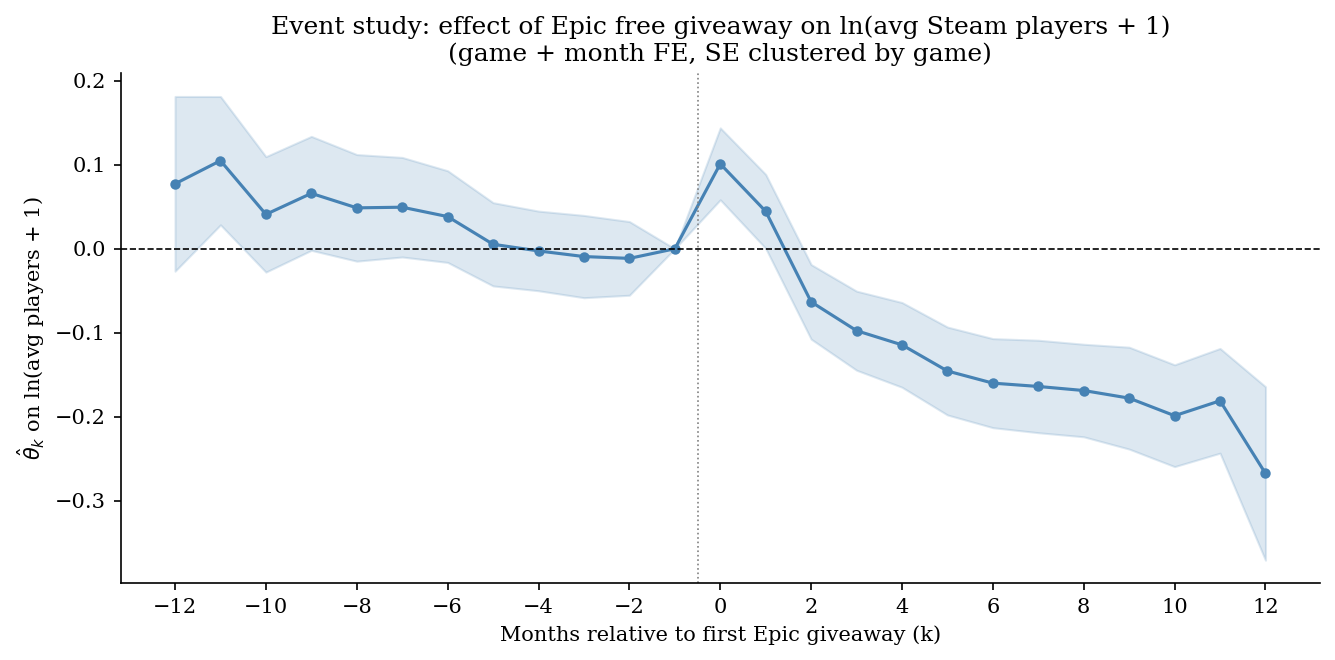

Saved fig_event_study_pooled


In [7]:
def plot_event_study(results_list, labels, title, fname,
                     colors=None, linestyles=None, k_min=K_MIN, k_max=K_MAX,
                     ylabel=r'$\hat{\theta}_k$ on ln(avg players + 1)'):
    """Plot one or more event-study coefficient paths with 95% CI ribbons."""
    if colors is None:
        colors = ['steelblue', 'coral', 'seagreen', 'purple']
    if linestyles is None:
        linestyles = ['-'] * len(results_list)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for res, label, color, ls in zip(results_list, labels, colors, linestyles):
        r = res[(res['k'] >= k_min) & (res['k'] <= k_max)]
        ax.fill_between(r['k'], r['ci_lo'], r['ci_hi'], alpha=0.18, color=color)
        ax.plot(r['k'], r['coef'], marker='o', markersize=4,
                linewidth=1.5, color=color, linestyle=ls, label=label)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(-0.5, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xlabel('Months relative to first Epic giveaway (k)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(range(k_min, k_max + 1, 2))
    if len(results_list) > 1:
        ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{fname}.pdf', bbox_inches='tight')
    fig.savefig(OUTPUT_DIR / f'{fname}.png', bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


plot_event_study(
    [es_twfe], ['Pooled TWFE'],
    'Event study: effect of Epic free giveaway on ln(avg Steam players + 1)\n'
    '(game + month FE, SE clustered by game)',
    'fig_event_study_pooled',
)

## 4. Pre-trend F-test

Joint Wald test $H_0: \theta_k = 0 \;\forall\, k \in [-12, -2]$.
Rejection indicates pre-existing trends, violating parallel trends.

In [8]:
from scipy.stats import f as f_dist

def pretrend_f_test(es_df, fit=None):
    """
    Joint pre-period test. Two flavours:
      • If `fit` is a pyfixest Feols object, we build a restriction matrix R
        picking out the pre-period event-time dummies and compute a proper
        joint Wald statistic using the **full clustered covariance matrix**:
            χ² = β̂_pre' (R V R')⁻¹ β̂_pre           (df = q)
        and its small-sample F analogue F = χ²/q with df₂ = G − 1 clusters.
      • If `fit` is None, we fall back to a diagonal χ² (sum of squared
        t-statistics) which assumes pre-period coefficients are independent.
        This is inconsistent with the clustered covariance structure and is
        kept only as a conservative sanity check — the proper Wald is the one
        we report.
    """
    pre = es_df[(es_df['k'] < 0) & (es_df['k'] != K_REF)].copy()
    n_pre = len(pre)
    k_lo = int(pre.k.min())
    print(f'Pre-trend joint test  (H₀: θ_k = 0 for k ∈ [{k_lo}, -2])')
    print(f'  N pre-period dummies: {n_pre}')

    if fit is not None:
        # Locate the pre-period event-time coefficients in the full β̂ vector
        names = list(fit._coefnames)
        idx = []
        for i, c in enumerate(names):
            if '[T.' not in c:
                continue
            try:
                kv = int(c.split('[T.')[1].rstrip(']'))
            except ValueError:
                continue
            if kv < 0 and kv != K_REF:
                idx.append(i)
        if not idx:
            raise RuntimeError('No pre-period coefficients found for Wald test')

        tidy = fit.tidy()
        beta_all = tidy['Estimate'].reindex(names).values
        V = fit._vcov
        beta_pre = beta_all[idx]
        V_pre    = V[np.ix_(idx, idx)]
        q        = len(idx)
        chi2_stat = float(beta_pre @ np.linalg.pinv(V_pre) @ beta_pre)
        p_chi2    = float(chi2_dist.sf(chi2_stat, df=q))

        # Small-sample F analogue using G clusters
        G = int(fit._G[0]) if hasattr(fit, '_G') else 1
        df2 = max(G - 1, 1)
        F_stat = chi2_stat / q
        p_F = float(f_dist.sf(F_stat, dfn=q, dfd=df2))

        # Diagonal for comparison
        se_pre = tidy['Std. Error'].reindex(names).values[idx]
        chi2_diag = float(np.sum((beta_pre / se_pre) ** 2))
        p_diag    = float(chi2_dist.sf(chi2_diag, df=q))

        print(f'  JOINT WALD (full V):')
        print(f'    χ² = {chi2_stat:.3f}  df={q}  p={p_chi2:.4f}')
        print(f'    F  = {F_stat:.3f}   df=({q},{df2})  p={p_F:.4f}')
        print(f'  Diagonal χ² (ignores off-diagonal V): {chi2_diag:.3f}  p={p_diag:.4f}')
    else:
        chi2_diag = float(np.sum((pre['coef'].values / pre['se'].values) ** 2))
        p_diag    = float(chi2_dist.sf(chi2_diag, df=n_pre))
        print(f'  [fallback] Diagonal χ²: {chi2_diag:.3f}  df={n_pre}  p={p_diag:.4f}')

    print()
    print(f'  {"k":>4}  {"coef":>8}  {"se":>7}  {"t":>7}  {"p":>7}')
    for _, row in pre.iterrows():
        pval_s = f'{row.pval:.3f}' if pd.notna(row.pval) else '   n/a'
        t_s    = f'{row.t:.3f}'    if pd.notna(row.t)    else '   n/a'
        print(f'  {row.k:>4.0f}  {row.coef:>8.4f}  {row.se:>7.4f}  {t_s:>7}  {pval_s:>7}')

# Use the proper joint Wald test on the TWFE fit
pretrend_f_test(es_twfe, fit=fit_twfe)

Pre-trend joint test  (H₀: θ_k = 0 for k ∈ [-12, -2])
  N pre-period dummies: 11
  JOINT WALD (full V):
    χ² = 18.889  df=11  p=0.0631
    F  = 1.717   df=(11,444)  p=0.0670
  Diagonal χ² (ignores off-diagonal V): 21.774  p=0.0262

     k      coef       se        t        p
   -12    0.0773   0.0529    1.461    0.145
   -11    0.1049   0.0389    2.699    0.007
   -10    0.0409   0.0350    1.171    0.242
    -9    0.0660   0.0345    1.912    0.057
    -8    0.0487   0.0323    1.508    0.132
    -7    0.0495   0.0301    1.641    0.102
    -6    0.0383   0.0278    1.380    0.168
    -5    0.0053   0.0252    0.211    0.833
    -4   -0.0026   0.0241   -0.107    0.915
    -3   -0.0093   0.0249   -0.372    0.710
    -2   -0.0115   0.0223   -0.513    0.608


## 5. Estimator comparison: TWFE vs. LP-DiD vs. stacked DiD

Heterogeneous-treatment-robust alternatives to TWFE:

- **LP-DiD** (Dube et al. 2023): local projections, uses not-yet-treated controls
- **Stacked DiD** (Cengiz et al. 2019): cohort-specific stacks with not-yet-treated
  controls, stacked and estimated with stack–unit FE and event-time dummies (weights
  = 1 / number of stacks per game)

Under treatment effect homogeneity all should coincide; divergence flags
heterogeneity or negative-weighting concerns in the pooled TWFE.

In [9]:
print('Estimating LP-DiD (Dube et al. 2023)...')
# lpdid requires a sequential integer time variable (not YYYYMM), because
# it computes period differences directly.
try:
    fit_lpdid = pf.lpdid(
        data=df,
        yname='ln_avg',
        idname='appid',
        tname='t_seq',
        gname='g_seq',
        vcov={'CRV1': 'appid'},
        pre_window=abs(K_MIN),
        post_window=K_MAX,
        never_treated=0,
        att=False,
    )
    lpdid_tidy = fit_lpdid.tidy().reset_index()
    # Parse k from "time_to_treatment::-12" style index
    lpdid_tidy['k'] = (
        lpdid_tidy['Coefficient']
        .str.extract(r'::(-?\d+)')[0]
        .astype(int)
    )
    lpdid_tidy = lpdid_tidy.rename(columns={
        'Estimate': 'coef', 'Std. Error': 'se',
        '2.5%': 'ci_lo', '97.5%': 'ci_hi',
    })[['k', 'coef', 'se', 'ci_lo', 'ci_hi']]
    LPDID_OK = True
    print('LP-DiD OK')
    print(lpdid_tidy.to_string(index=False))
except Exception as e:
    print(f'LP-DiD failed: {e}')
    LPDID_OK = False

# ── Stacked DiD (Cengiz et al. 2019; Baker–Larcker–Wang 2022) ────────────────
# For each quarter-of-first-giveaway cohort g we build a balanced stack:
#   • treated units  : games first given away in quarter g, k ∈ [−12, 12]
#     relative to their own first_giveaway_date;  treated=1.
#   • control units  : not-yet-treated games (first_giveaway strictly after any
#     treated game in cohort g) observed over the same calendar window relative
#     to the cohort's earliest treatment month; treated=0.
# The regression interacts the event-time dummies with the treated indicator,
# so that the β_k are identified only from the differential trajectory of
# treated units after netting out stack-by-calendar-time shocks.  Stack × time
# fixed effects absorb aggregate shocks inside each stack; unit-within-stack
# fixed effects absorb time-invariant game heterogeneity.  Games appearing in
# multiple stacks are weighted by 1/n_stacks.
print('Estimating stacked DiD (Cengiz et al. 2019)...')
try:
    meta = (
        df.drop_duplicates('appid')
        .set_index('appid')[['first_giveaway_date', 'cohort_q']]
    )
    cohorts = sorted(meta['cohort_q'].unique())
    stack_dfs = []

    for g in cohorts:
        treated_ids = meta[meta['cohort_q'] == g].index.tolist()
        g_start = meta.loc[treated_ids, 'first_giveaway_date'].min()
        control_ids = meta[meta['first_giveaway_date'] > g_start].index.tolist()
        if not control_ids:
            continue

        trt = df[df['appid'].isin(treated_ids) & df['k'].between(K_MIN, K_MAX)].copy()
        trt['stack_id'] = g
        trt['k_stacked'] = trt['k'].astype(int)
        trt['treated'] = 1

        ctrl = df[df['appid'].isin(control_ids)].copy()
        ctrl['k_g'] = (
            (ctrl['month'].dt.year - g_start.year) * 12
            + (ctrl['month'].dt.month - g_start.month)
        )
        ctrl = ctrl[ctrl['k_g'].between(K_MIN, K_MAX)].copy()
        ctrl['stack_id'] = g
        ctrl['k_stacked'] = ctrl['k_g'].astype(int)
        ctrl['treated'] = 0

        cols = ['appid', 'month', 't_ym', 'ln_avg',
                'stack_id', 'k_stacked', 'treated']
        stack_dfs.append(pd.concat([trt[cols], ctrl[cols]], ignore_index=True))

    stacked = pd.concat(stack_dfs, ignore_index=True)
    stacked['unit_id']    = stacked['stack_id'].astype(str) + '_' + stacked['appid'].astype(str)
    stacked['stack_time'] = stacked['stack_id'].astype(str) + '_' + stacked['t_ym'].astype(str)

    n_stacks = stacked.groupby('appid')['stack_id'].nunique()
    stacked  = stacked.merge(n_stacks.rename('n_stacks'),
                             left_on='appid', right_index=True)
    stacked['weight'] = 1.0 / stacked['n_stacks']

    # Canonical stacked DiD: event-time × treated interactions, with
    # unit and stack-by-calendar-time FEs, clustered SE by game.
    fit_stack = pf.feols(
        'ln_avg ~ i(k_stacked, treated, ref=-1) | unit_id + stack_time',
        data=stacked,
        weights='weight',
        vcov={'CRV1': 'appid'},
    )
    stack_tidy = fit_stack.tidy().reset_index()
    coef_col = 'Coefficient' if 'Coefficient' in stack_tidy.columns else stack_tidy.columns[0]
    # Interaction rows look like: C(k_stacked, contr.treatment(base=-1))[-4]:treated
    stack_tidy = stack_tidy[
        stack_tidy[coef_col].astype(str)
        .str.contains(r'\[-?\d+\]:treated$', na=False)
    ].copy()
    stack_tidy['k'] = (
        stack_tidy[coef_col].astype(str)
        .str.extract(r'\[(-?\d+)\]:treated')[0]
        .astype(int)
    )
    stack_tidy = stack_tidy.rename(columns={
        'Estimate': 'coef', 'Std. Error': 'se',
        '2.5%': 'ci_lo', '97.5%': 'ci_hi',
    })
    if 'ci_lo' not in stack_tidy.columns:
        stack_tidy['ci_lo'] = stack_tidy['coef'] - 1.96 * stack_tidy['se']
        stack_tidy['ci_hi'] = stack_tidy['coef'] + 1.96 * stack_tidy['se']
    stack_tidy = stack_tidy[['k', 'coef', 'se', 'ci_lo', 'ci_hi']].sort_values('k')
    STACK_OK = True
    print('Stacked DiD OK')
    print(stack_tidy.to_string(index=False))
except Exception as e:
    print(f'Stacked DiD failed: {e}')
    import traceback
    traceback.print_exc()
    STACK_OK = False

Estimating LP-DiD (Dube et al. 2023)...


LP-DiD OK
  k      coef       se     ci_lo     ci_hi
-12  0.070418 0.040124 -0.008475  0.149310
-11  0.063168 0.036693 -0.008974  0.135310
-10 -0.004007 0.034860 -0.072544  0.064531
 -9  0.006005 0.037782 -0.068272  0.080282
 -8  0.012541 0.031579 -0.049540  0.074622
 -7  0.010595 0.029736 -0.047860  0.069049
 -6 -0.008573 0.027777 -0.063176  0.046029
 -5 -0.034072 0.023632 -0.080525  0.012381
 -4 -0.045681 0.022825 -0.090547 -0.000815
 -3 -0.045258 0.022661 -0.089801 -0.000715
 -2 -0.026276 0.020703 -0.066969  0.014416
  0  0.130690 0.021771  0.087900  0.173481
  1  0.098626 0.023210  0.053006  0.144245
  2  0.000231 0.022586 -0.044164  0.044626
  3 -0.018097 0.025102 -0.067437  0.031244
  4 -0.040200 0.026476 -0.092241  0.011842
  5 -0.063566 0.028871 -0.120315 -0.006817
  6 -0.069574 0.029320 -0.127205 -0.011944
  7 -0.069519 0.030784 -0.130029 -0.009009
  8 -0.082606 0.031698 -0.144912 -0.020299
  9 -0.082959 0.035556 -0.152849 -0.013069
 10 -0.120810 0.035509 -0.190609 -0.051012
 

Stacked DiD OK
  k      coef       se     ci_lo     ci_hi
-12  0.122914 0.033186  0.057689  0.188138
-11  0.125700 0.035336  0.056250  0.195150
-10  0.066529 0.043962 -0.019873  0.152931
 -9  0.060538 0.031748 -0.001860  0.122936
 -8  0.017976 0.024345 -0.029871  0.065823
 -7  0.034888 0.026087 -0.016382  0.086159
 -6  0.019889 0.023017 -0.025348  0.065126
 -5 -0.010701 0.021592 -0.053138  0.031736
 -4 -0.024002 0.017328 -0.058058  0.010054
 -3 -0.016786 0.019857 -0.055813  0.022241
 -2 -0.013130 0.021407 -0.055203  0.028943
  0  0.101084 0.020623  0.060552  0.141616
  1  0.049099 0.016629  0.016417  0.081781
  2 -0.040260 0.020523 -0.080595  0.000075
  3 -0.062078 0.016356 -0.094224 -0.029932
  4 -0.067703 0.019369 -0.105771 -0.029635
  5 -0.096953 0.019510 -0.135298 -0.058608
  6 -0.090046 0.021144 -0.131602 -0.048490
  7 -0.071680 0.020974 -0.112903 -0.030458
  8 -0.063972 0.018646 -0.100619 -0.027325
  9 -0.054533 0.023092 -0.099918 -0.009149
 10 -0.061439 0.022581 -0.105819 -0.017

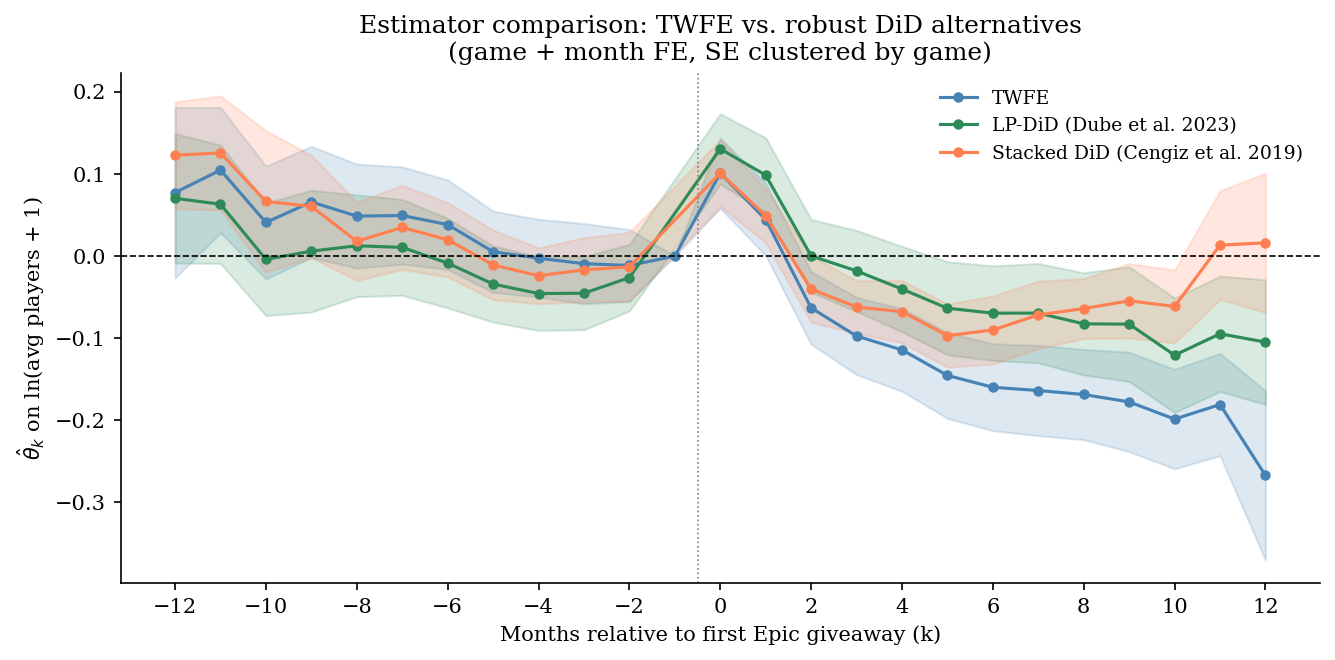

Saved fig_estimator_comparison


In [10]:
# Build comparison plot from whichever estimators succeeded
results_to_plot = [es_twfe]
labels_to_plot  = ['TWFE']
colors_to_plot  = ['steelblue']

if LPDID_OK:
    results_to_plot.append(lpdid_tidy)
    labels_to_plot.append('LP-DiD (Dube et al. 2023)')
    colors_to_plot.append('seagreen')
if STACK_OK:
    results_to_plot.append(stack_tidy)
    labels_to_plot.append('Stacked DiD (Cengiz et al. 2019)')
    colors_to_plot.append('coral')

plot_event_study(
    results_to_plot, labels_to_plot,
    'Estimator comparison: TWFE vs. robust DiD alternatives\n'
    '(game + month FE, SE clustered by game)',
    'fig_estimator_comparison',
    colors=colors_to_plot,
)

## 6. Separated specification

Adds `repeat_event_it` as a control to isolate the first-giveaway effect $\beta_k$
from contamination by proximate repeat giveaways:

$$\ln(y_{it}+1) = \alpha_i + \gamma_t
  + \sum_{k \neq -1} \beta_k \cdot \mathbf{1}[\tilde{k}_{it}=k]
  + \delta\cdot\text{repeat\_event\_it}
  + \varepsilon_{it}$$

Also estimates the robustness check excluding games with proximate repeats entirely.

Estimating separated specification...



repeat_event_it coefficient:
  Estimate : 0.0001
  SE       : 0.0609
  t-stat   : 0.002
  p-value  : 0.9987


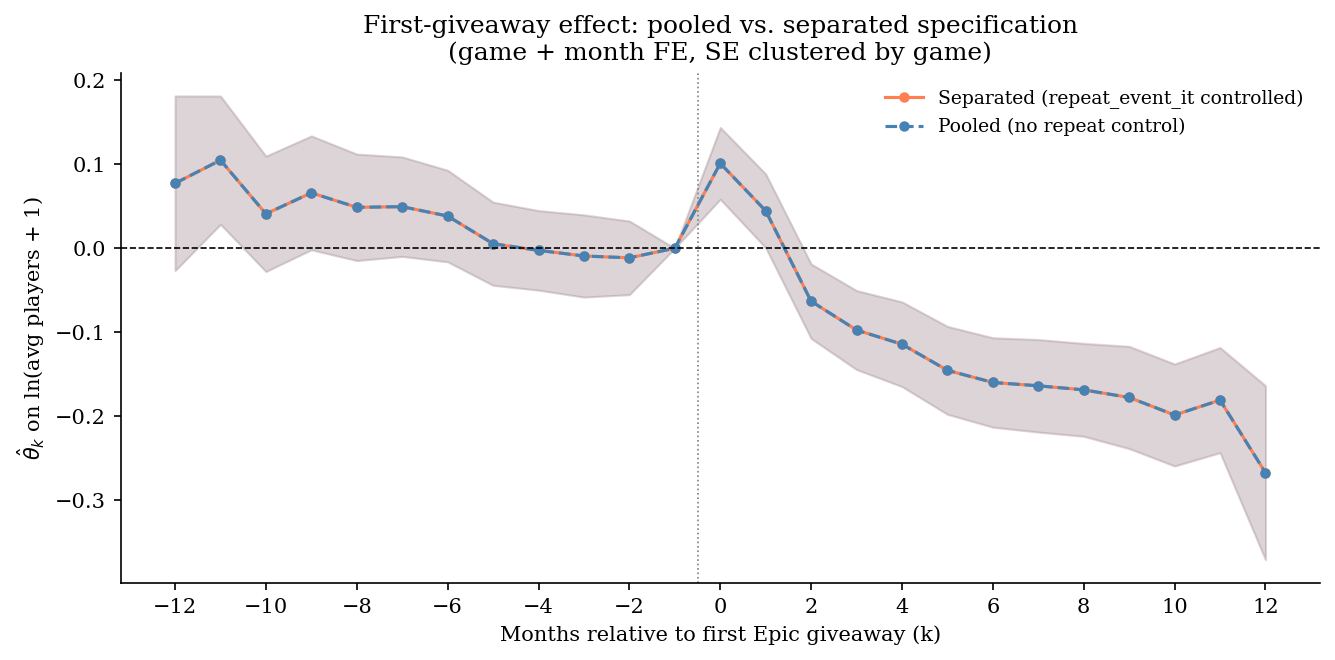

Saved fig_event_study_separated


In [11]:
print('Estimating separated specification...')
fit_sep = pf.feols(
    'ln_avg ~ i(k_clip, ref=-1) + repeat_event_it | appid + t_ym',
    data=df,
    vcov={'CRV1': 'appid'},
)
es_sep = parse_event_study(fit_sep)

# Repeat-event coefficient
repeat_coef = fit_sep.tidy().loc['repeat_event_it'] if 'repeat_event_it' in fit_sep.tidy().index else None
if repeat_coef is not None:
    print(f"\nrepeat_event_it coefficient:")
    print(f"  Estimate : {repeat_coef['Estimate']:.4f}")
    print(f"  SE       : {repeat_coef['Std. Error']:.4f}")
    print(f"  t-stat   : {repeat_coef['t value']:.3f}")
    print(f"  p-value  : {repeat_coef['Pr(>|t|)']:.4f}")

plot_event_study(
    [es_sep, es_twfe],
    ['Separated (repeat_event_it controlled)', 'Pooled (no repeat control)'],
    'First-giveaway effect: pooled vs. separated specification\n'
    '(game + month FE, SE clustered by game)',
    'fig_event_study_separated',
    colors=['coral', 'steelblue'],
    linestyles=['-', '--'],
)

Games with a proximate repeat: 30
Clean sample: 416 games, 36,123 rows
Estimating on clean sample...


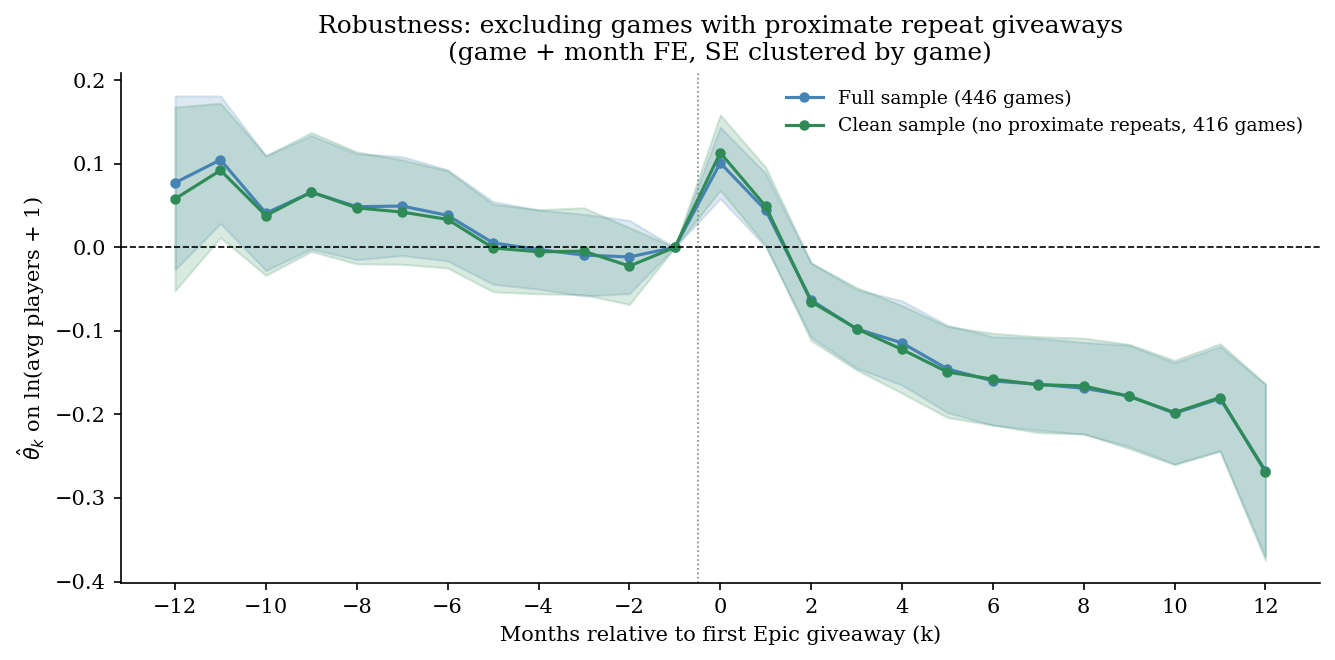

Saved fig_event_study_robustness


In [12]:
# Robustness: drop games that have any proximate repeat (≤12 months after first)
def has_proximate_repeat(dates_str):
    if not isinstance(dates_str, str):
        return False
    dates = [pd.Timestamp(d) for d in dates_str.split(';')]
    if len(dates) <= 1:
        return False
    first = dates[0]
    for d in dates[1:]:
        gap = (d.year - first.year) * 12 + (d.month - first.month)
        if 0 < gap <= 12:
            return True
    return False

prox_appids = set(
    df.drop_duplicates('appid')
    .query('all_giveaway_dates == all_giveaway_dates')  # drop NaN
    [lambda g: g['all_giveaway_dates'].apply(has_proximate_repeat)]['appid']
)
print(f'Games with a proximate repeat: {len(prox_appids)}')

df_clean = df[~df['appid'].isin(prox_appids)].copy()
print(f'Clean sample: {df_clean["appid"].nunique()} games, {len(df_clean):,} rows')

print('Estimating on clean sample...')
fit_clean = pf.feols(
    'ln_avg ~ i(k_clip, ref=-1) | appid + t_ym',
    data=df_clean,
    vcov={'CRV1': 'appid'},
)
es_clean = parse_event_study(fit_clean)

plot_event_study(
    [es_twfe, es_clean],
    [f'Full sample ({df["appid"].nunique()} games)',
     f'Clean sample (no proximate repeats, {df_clean["appid"].nunique()} games)'],
    'Robustness: excluding games with proximate repeat giveaways\n'
    '(game + month FE, SE clustered by game)',
    'fig_event_study_robustness',
    colors=['steelblue', 'seagreen'],
)

Dropping 73 holiday-batch games, leaving 373 games and 32,108 game-months


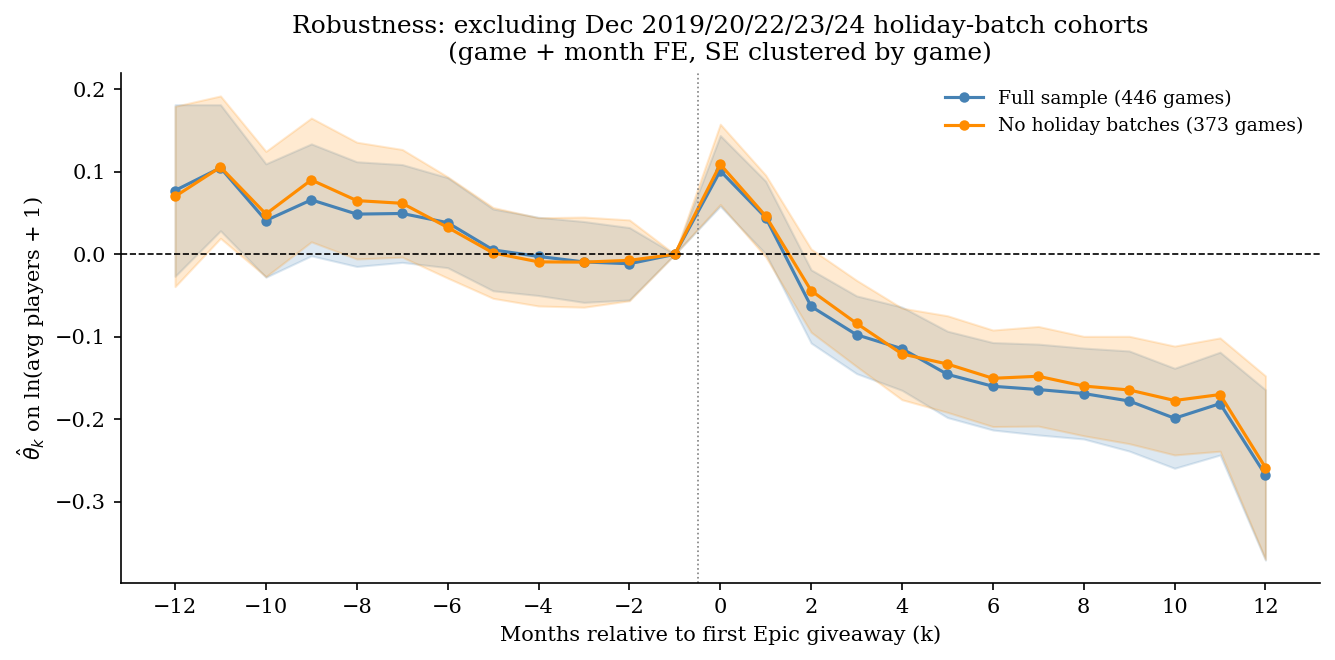

Saved fig_event_study_no_holiday

No-holiday pre-trend joint Wald test:
Pre-trend joint test  (H₀: θ_k = 0 for k ∈ [-12, -2])
  N pre-period dummies: 11
  JOINT WALD (full V):
    χ² = 18.641  df=11  p=0.0679
    F  = 1.695   df=(11,371)  p=0.0726
  Diagonal χ² (ignores off-diagonal V): 22.723  p=0.0193

     k      coef       se        t        p
   -12    0.0701   0.0556    1.261    0.208
   -11    0.1056   0.0439    2.409    0.017
   -10    0.0488   0.0386    1.265    0.207
    -9    0.0901   0.0381    2.363    0.019
    -8    0.0651   0.0360    1.808    0.071
    -7    0.0618   0.0332    1.862    0.063
    -6    0.0326   0.0312    1.043    0.298
    -5    0.0017   0.0280    0.060    0.952
    -4   -0.0092   0.0272   -0.338    0.736
    -3   -0.0095   0.0278   -0.342    0.733
    -2   -0.0073   0.0249   -0.294    0.769


In [13]:
# ── Holiday-batch robustness ────────────────────────────────────────────────
# Epic's December holiday "15 days of free games" batches (Dec 2019, 2020,
# 2022, 2023, 2024) compress many giveaway announcements into one burst of
# media attention.  As a robustness check we re-estimate TWFE after dropping
# games whose FIRST giveaway falls in any of those months.
holiday_months = {201912, 202012, 202212, 202312, 202412}
holiday_ids = (
    df.drop_duplicates('appid')
      .query('g_ym in @holiday_months')['appid']
      .tolist()
)
df_noholiday = df[~df['appid'].isin(holiday_ids)].copy()
print(f'Dropping {len(holiday_ids)} holiday-batch games, '
      f'leaving {df_noholiday["appid"].nunique()} games '
      f'and {len(df_noholiday):,} game-months')

fit_noholiday = pf.feols(
    'ln_avg ~ i(k_clip, ref=-1) | appid + t_ym',
    data=df_noholiday,
    vcov={'CRV1': 'appid'},
)
es_noholiday = parse_event_study(fit_noholiday)

plot_event_study(
    [es_twfe, es_noholiday],
    [f'Full sample ({df["appid"].nunique()} games)',
     f'No holiday batches ({df_noholiday["appid"].nunique()} games)'],
    'Robustness: excluding Dec 2019/20/22/23/24 holiday-batch cohorts\n'
    '(game + month FE, SE clustered by game)',
    'fig_event_study_no_holiday',
    colors=['steelblue', 'darkorange'],
)

print('\nNo-holiday pre-trend joint Wald test:')
pretrend_f_test(es_noholiday, fit=fit_noholiday)

## 7. Cohort-level ATTs (Callaway–Sant'Anna style)

For each treatment cohort $g$ (games first given away in the same quarter), estimates
$\widehat{\text{ATT}}(g, k)$ using **not-yet-treated** games as controls:

$$\widehat{\text{ATT}}(g, k) =
  \left(\bar{y}^{\text{trt}}_{g,k} - \bar{y}^{\text{trt}}_{g,-1}\right)
  - \left(\bar{y}^{\text{ctrl}}_{g,k} - \bar{y}^{\text{ctrl}}_{g,-1}\right)$$

Aggregated across cohorts weighted by cohort size.

In [14]:
def cohort_att(df, outcome='ln_avg', k_min=K_MIN, k_max=K_MAX):
    """Cohort-level ATT(g,k) via not-yet-treated 2×2 DiD."""
    meta = (
        df.drop_duplicates('appid')
        .set_index('appid')[['first_giveaway_date', 'cohort_q']]
    )
    cohorts = sorted(meta['cohort_q'].unique())
    records = []

    for g in cohorts:
        treated_ids  = meta[meta['cohort_q'] == g].index.tolist()
        g_start      = meta.loc[treated_ids, 'first_giveaway_date'].min()
        # Controls: games whose first giveaway is strictly after this cohort
        control_ids  = meta[meta['first_giveaway_date'] > g_start].index.tolist()
        if not control_ids:
            continue

        trt_panel = df[df['appid'].isin(treated_ids)][['k', outcome]]
        ctrl_rows = df[df['appid'].isin(control_ids)].copy()
        ctrl_rows['k_g'] = (
            (ctrl_rows['month'].dt.year  - g_start.year)  * 12 +
            (ctrl_rows['month'].dt.month - g_start.month)
        )

        t_ref = trt_panel[trt_panel['k'] == -1][outcome].mean()
        c_ref = ctrl_rows[ctrl_rows['k_g'] == -1][outcome].mean()
        if np.isnan(t_ref) or np.isnan(c_ref):
            continue

        for k in range(k_min, k_max + 1):
            t_k = trt_panel[trt_panel['k'] == k][outcome].mean()
            c_k = ctrl_rows[ctrl_rows['k_g'] == k][outcome].mean()
            if np.isnan(t_k) or np.isnan(c_k):
                continue
            records.append({
                'cohort_q' : g,
                'k'        : k,
                'att'      : (t_k - c_k) - (t_ref - c_ref),
                'n_treated': len(treated_ids),
                'n_control': len(control_ids),
            })

    return pd.DataFrame(records)


print('Estimating cohort-level ATTs...')
cs_df = cohort_att(df)
n_cohorts = cs_df['cohort_q'].nunique()
print(f'Done. {n_cohorts} cohorts with valid estimates.')

# Aggregate (weighted by cohort size)
cs_agg = (
    cs_df.groupby('k')
    .apply(lambda g: np.average(g['att'], weights=g['n_treated']))
    .reset_index(name='coef')
)
# Naive SE across cohorts
cs_se = (
    cs_df.groupby('k')['att']
    .std() / np.sqrt(cs_df.groupby('k')['cohort_q'].nunique())
).reset_index(name='se')
cs_agg = cs_agg.merge(cs_se, on='k')
cs_agg['ci_lo'] = cs_agg['coef'] - 1.96 * cs_agg['se']
cs_agg['ci_hi'] = cs_agg['coef'] + 1.96 * cs_agg['se']
print(cs_agg.to_string(index=False))

Estimating cohort-level ATTs...


Done. 27 cohorts with valid estimates.
  k      coef       se     ci_lo     ci_hi
-12 -0.019883 0.071251 -0.159534  0.119769
-11  0.024630 0.079038 -0.130285  0.179545
-10 -0.054003 0.076462 -0.203869  0.095863
 -9 -0.074471 0.073682 -0.218887  0.069945
 -8 -0.014866 0.054571 -0.121825  0.092093
 -7  0.001670 0.048080 -0.092568  0.095907
 -6 -0.015646 0.051993 -0.117552  0.086260
 -5  0.035295 0.049233 -0.061201  0.131791
 -4 -0.055611 0.043224 -0.140330  0.029108
 -3 -0.074517 0.047165 -0.166961  0.017926
 -2 -0.006109 0.046328 -0.096912  0.084693
 -1  0.000000 0.000000  0.000000  0.000000
  0  0.048450 0.039773 -0.029505  0.126406
  1  0.058213 0.041845 -0.023803  0.140228
  2 -0.082305 0.054356 -0.188843  0.024233
  3 -0.149673 0.056241 -0.259906 -0.039440
  4 -0.065749 0.058346 -0.180107  0.048610
  5 -0.113806 0.054004 -0.219654 -0.007958
  6 -0.142891 0.053432 -0.247618 -0.038164
  7 -0.054621 0.058328 -0.168944  0.059702
  8 -0.047714 0.050669 -0.147025  0.051598
  9 -0.114207 0

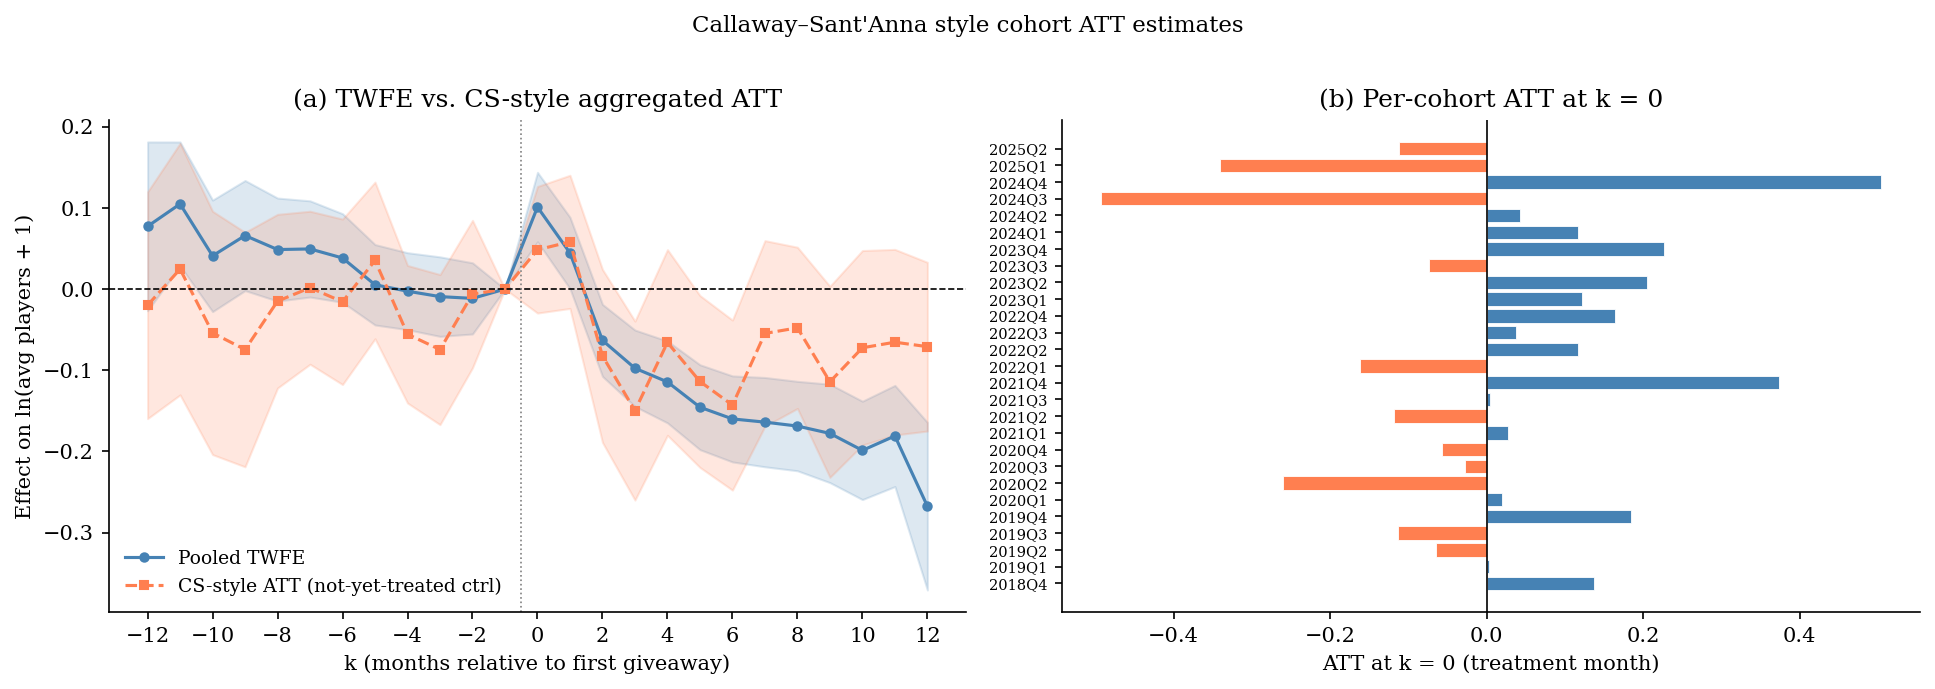

Saved fig_cs_att


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Aggregated CS ATT vs. TWFE
ax = axes[0]
for res, label, color in [
    (es_twfe,  'Pooled TWFE', 'steelblue'),
    (cs_agg,   'CS-style ATT (not-yet-treated ctrl)', 'coral'),
]:
    r = res[(res['k'] >= K_MIN) & (res['k'] <= K_MAX)]
    ax.fill_between(r['k'], r['ci_lo'], r['ci_hi'], alpha=0.18, color=color)
    ax.plot(r['k'], r['coef'], marker='o' if color == 'steelblue' else 's',
            markersize=4, linewidth=1.5, color=color,
            linestyle='-' if color == 'steelblue' else '--', label=label)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(-0.5, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('k (months relative to first giveaway)')
ax.set_ylabel('Effect on ln(avg players + 1)')
ax.set_title('(a) TWFE vs. CS-style aggregated ATT')
ax.set_xticks(range(K_MIN, K_MAX + 1, 2))
ax.legend(frameon=False, fontsize=9)

# (b) Per-cohort ATT at k = 0
ax = axes[1]
cohort_k0 = (
    cs_df[cs_df['k'] == 0]
    [['cohort_q', 'att', 'n_treated']]
    .sort_values('cohort_q')
)
bar_colors = ['steelblue' if v >= 0 else 'coral' for v in cohort_k0['att']]
ax.barh(cohort_k0['cohort_q'].astype(str), cohort_k0['att'],
        color=bar_colors, edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('ATT at k = 0 (treatment month)')
ax.set_title('(b) Per-cohort ATT at k = 0')
ax.tick_params(axis='y', labelsize=7)

fig.suptitle("Callaway\u2013Sant'Anna style cohort ATT estimates", fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_cs_att.pdf', bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'fig_cs_att.png', bbox_inches='tight')
plt.show()
print('Saved fig_cs_att')

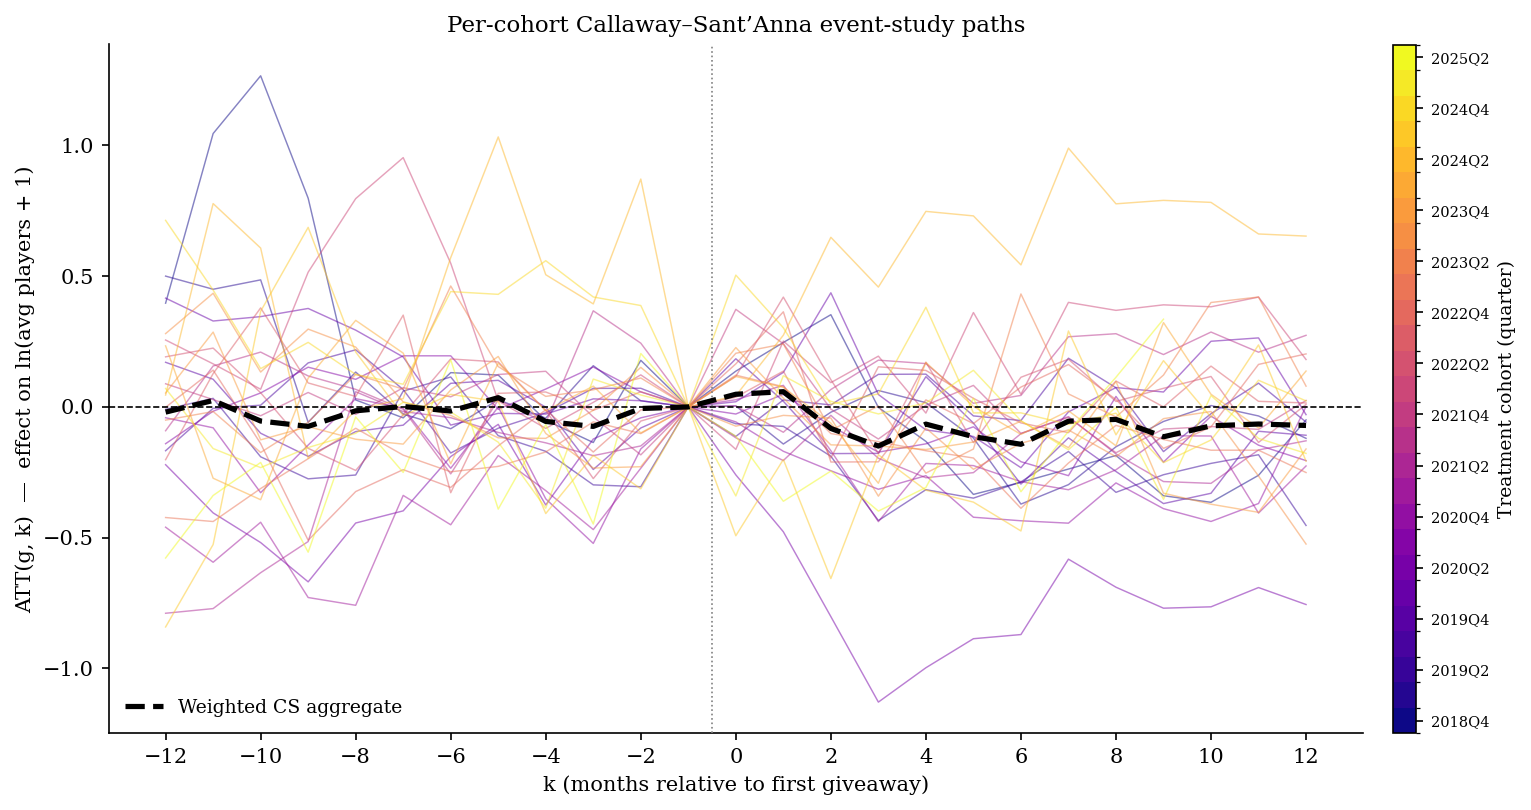

Saved fig_cs_cohort_event_study  (27 cohorts)


In [16]:
# ── Figure: Per-cohort event-study paths (CS ATT) ─────────────────────────
import matplotlib.cm as cm
import matplotlib.colors as mcolors

cohort_order = sorted(cs_df['cohort_q'].unique())
n_cohorts    = len(cohort_order)
cmap         = cm.get_cmap('plasma', n_cohorts)
cohort_rank  = {g: i for i, g in enumerate(cohort_order)}

fig, ax = plt.subplots(figsize=(11, 5.5))

# One thin line per cohort
for g, grp in cs_df.groupby('cohort_q'):
    grp_sorted = grp.sort_values('k')
    color = cmap(cohort_rank[g] / max(n_cohorts - 1, 1))
    ax.plot(grp_sorted['k'], grp_sorted['att'],
            color=color, linewidth=0.7, alpha=0.5)

# Weighted CS aggregate overlay
ax.plot(cs_agg['k'], cs_agg['coef'],
        color='black', linewidth=2.5, linestyle='--',
        label='Weighted CS aggregate', zorder=5)

# Reference lines
ax.axhline(0,    color='black', linewidth=0.8, linestyle='--', zorder=3)
ax.axvline(-0.5, color='gray',  linewidth=0.8, linestyle=':',  zorder=3)

ax.set_xlabel('k (months relative to first giveaway)')
ax.set_ylabel('ATT(g, k)  —  effect on ln(avg players + 1)')
ax.set_title('Per-cohort Callaway\u2013Sant\u2019Anna event-study paths', fontsize=11)
ax.set_xticks(range(K_MIN, K_MAX + 1, 2))
ax.legend(frameon=False, fontsize=9, loc='lower left')

# Colorbar with readable cohort labels
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=mcolors.BoundaryNorm(range(n_cohorts + 1), n_cohorts)
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=30)

tick_step = max(1, n_cohorts // 10)
tick_idxs = list(range(0, n_cohorts, tick_step))
if (n_cohorts - 1) not in tick_idxs:
    tick_idxs.append(n_cohorts - 1)
cbar.set_ticks([i + 0.5 for i in tick_idxs])
cbar.set_ticklabels([str(cohort_order[i]) for i in tick_idxs])
cbar.ax.tick_params(labelsize=7)
cbar.set_label('Treatment cohort (quarter)', fontsize=9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_cs_cohort_event_study.pdf', bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'fig_cs_cohort_event_study.png', bbox_inches='tight')
plt.show()
print(f'Saved fig_cs_cohort_event_study  ({n_cohorts} cohorts)')

## 8. Popularity-stratified analysis

Split the sample at the **pre-treatment median** of `avg_players` (computed across each
game's pre-period observations) and re-estimate the pooled TWFE separately for
high- and low-traffic games.

If flat pre-trends hold for high-traffic games but not for low-traffic ones, the
pooled estimate is driven by noisy near-zero games and should be interpreted with
caution.

Popularity split: median pre-treatment avg_players = 59.24
High-traffic games: 215  |  Low-traffic games: 214
Estimating TWFE on high-traffic subsample...


Estimating TWFE on low-traffic subsample...


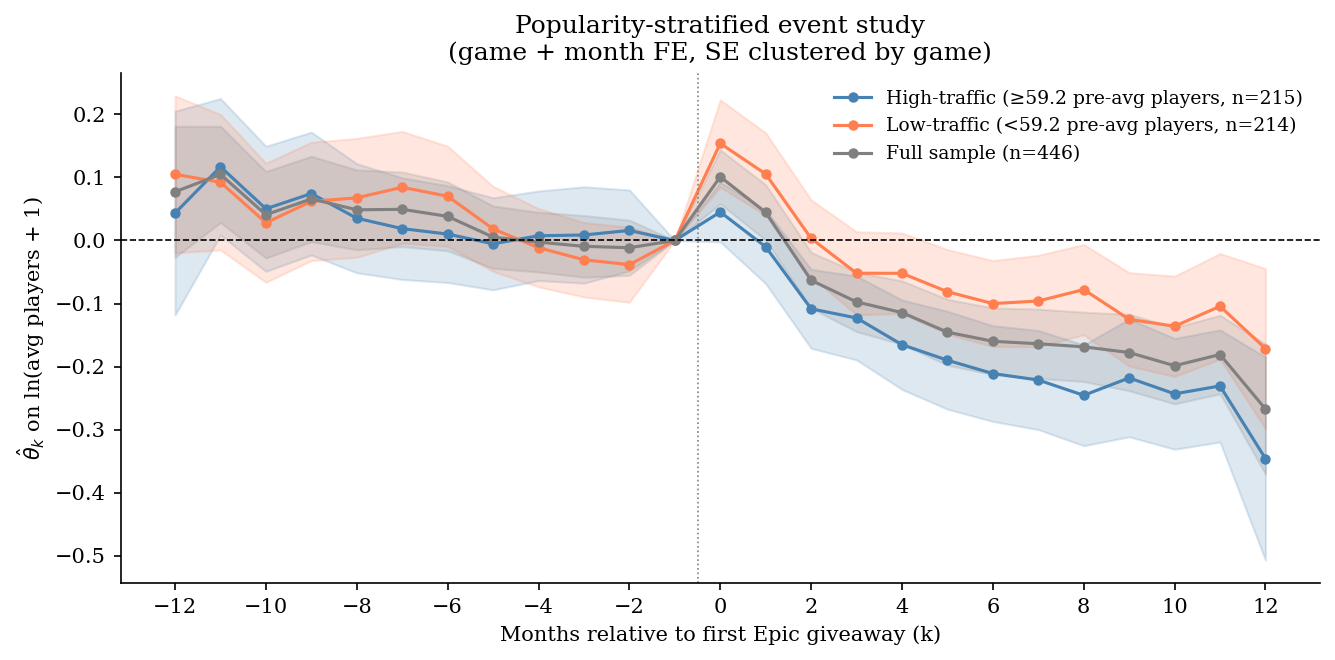

Saved fig_event_study_popularity

High-traffic pre-trend test:
Pre-trend joint test  (H₀: θ_k = 0 for k ∈ [-12, -2])
  N pre-period dummies: 11
  JOINT WALD (full V):
    χ² = 9.042  df=11  p=0.6180
    F  = 0.822   df=(11,214)  p=0.6181
  Diagonal χ² (ignores off-diagonal V): 9.353  p=0.5894

     k      coef       se        t        p
   -12    0.0435   0.0821    0.529    0.597
   -11    0.1170   0.0550    2.127    0.035
   -10    0.0503   0.0504    0.999    0.319
    -9    0.0745   0.0495    1.506    0.133
    -8    0.0354   0.0440    0.804    0.422
    -7    0.0188   0.0410    0.460    0.646
    -6    0.0102   0.0390    0.261    0.794
    -5   -0.0053   0.0371   -0.142    0.887
    -4    0.0075   0.0361    0.209    0.835
    -3    0.0087   0.0388    0.225    0.822
    -2    0.0160   0.0326    0.489    0.625

Low-traffic pre-trend test:
Pre-trend joint test  (H₀: θ_k = 0 for k ∈ [-12, -2])
  N pre-period dummies: 11
  JOINT WALD (full V):
    χ² = 20.824  df=11  p=0.0352
    F  = 1.

In [17]:
# Pre-treatment median players per game (reuse 'pre' from section 2 if available)
pre_med = df[df['k'] < 0].groupby('appid')['avg_players'].median()
split_val = pre_med.median()
print(f'Popularity split: median pre-treatment avg_players = {split_val:.2f}')

high_ids = pre_med[pre_med >= split_val].index
low_ids  = pre_med[pre_med <  split_val].index
print(f'High-traffic games: {len(high_ids)}  |  Low-traffic games: {len(low_ids)}')

df_high = df[df['appid'].isin(high_ids)]
df_low  = df[df['appid'].isin(low_ids)]

print('Estimating TWFE on high-traffic subsample...')
fit_high = pf.feols(
    'ln_avg ~ i(k_clip, ref=-1) | appid + t_ym',
    data=df_high,
    vcov={'CRV1': 'appid'},
)
es_high = parse_event_study(fit_high)

print('Estimating TWFE on low-traffic subsample...')
fit_low = pf.feols(
    'ln_avg ~ i(k_clip, ref=-1) | appid + t_ym',
    data=df_low,
    vcov={'CRV1': 'appid'},
)
es_low = parse_event_study(fit_low)

plot_event_study(
    [es_high, es_low, es_twfe],
    [f'High-traffic (≥{split_val:.1f} pre-avg players, n={len(high_ids)})',
     f'Low-traffic (<{split_val:.1f} pre-avg players, n={len(low_ids)})',
     f'Full sample (n={df["appid"].nunique()})'],
    'Popularity-stratified event study\n'
    '(game + month FE, SE clustered by game)',
    'fig_event_study_popularity',
    colors=['steelblue', 'coral', 'gray'],
)

# Pre-trend joint Wald tests for each subsample (using the full clustered V)
print('\nHigh-traffic pre-trend test:')
pretrend_f_test(es_high, fit=fit_high)
print('\nLow-traffic pre-trend test:')
pretrend_f_test(es_low,  fit=fit_low)

## 9. Randomization placebo

Permute treatment dates across the 446 games (preserving the empirical distribution
of treatment months) and re-estimate the pooled TWFE **200 times**.

If the actual $|\hat{\theta}_0|$ lies in the right tail of the null distribution, the
treatment-month spike is unlikely to arise by chance from the panel's time-series
structure alone.

Actual θ̂_0 = 0.1011


  50/200 permutations done (13.9s elapsed)


  100/200 permutations done (26.2s elapsed)


  150/200 permutations done (40.3s elapsed)


  200/200 permutations done (52.6s elapsed)

Permutation p-value (two-sided): 0.0000
Actual |θ̂_0| = 0.1011
Permutation 95th pctile of |θ̂_0|: 0.0378


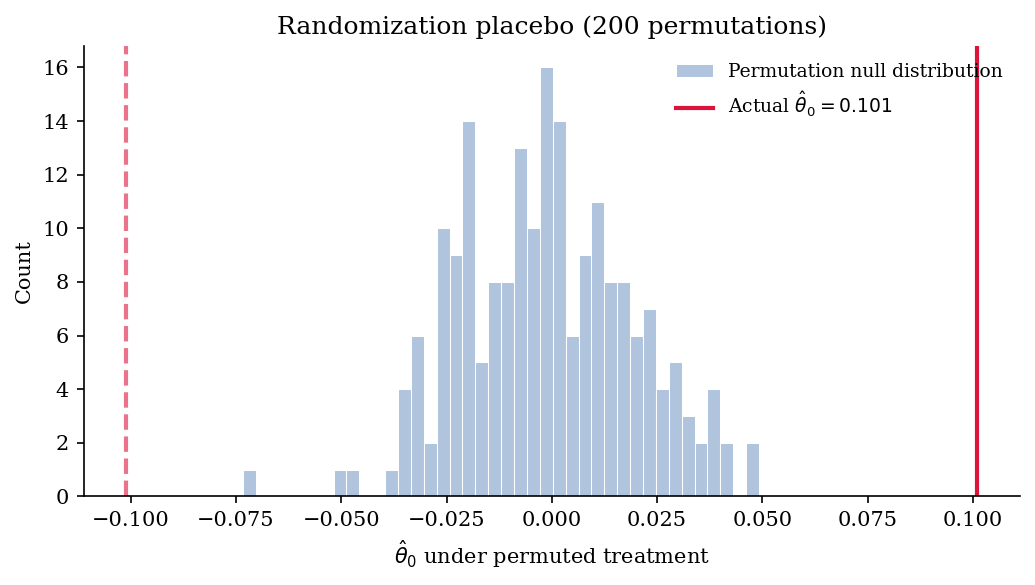

Saved fig_randomization_placebo


In [18]:
import time

N_PERMS = 200
rng = np.random.default_rng(42)

# Actual treatment-month estimate from the full-sample TWFE
actual_theta0 = es_twfe.loc[es_twfe['k'] == 0, 'coef'].values[0]
print(f'Actual θ̂_0 = {actual_theta0:.4f}')

# Build a minimal permutation panel: only the columns we need
# (avoids rebuilding the full df each iteration)
game_treats = (
    df.drop_duplicates('appid')[['appid', 'g_seq']]
    .set_index('appid')['g_seq']
)
all_g_seqs = game_treats.values.copy()   # pool of treatment dates to shuffle

perm_theta0s = []
t0 = time.time()
for i in range(N_PERMS):
    shuffled = rng.permutation(all_g_seqs)
    g_seq_map = dict(zip(game_treats.index, shuffled))

    df_perm = df[['appid', 'ln_avg', 't_seq', 't_ym']].copy()
    df_perm['g_seq_perm'] = df_perm['appid'].map(g_seq_map)
    df_perm['k_perm'] = (df_perm['t_seq'] - df_perm['g_seq_perm']).clip(K_MIN, K_MAX)

    try:
        fit_p = pf.feols(
            'ln_avg ~ i(k_perm, ref=-1) | appid + t_ym',
            data=df_perm,
            vcov='iid',   # faster; we only need point estimates
        )
        tidy_p = fit_p.tidy().reset_index()
        row0 = tidy_p[tidy_p['Coefficient'].str.contains(r'\[T\.0\]', na=False)]
        if not row0.empty:
            perm_theta0s.append(row0['Estimate'].values[0])
    except Exception:
        pass

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t0
        print(f'  {i+1}/{N_PERMS} permutations done ({elapsed:.1f}s elapsed)')

perm_theta0s = np.array(perm_theta0s)
p_val = np.mean(np.abs(perm_theta0s) >= np.abs(actual_theta0))
print(f'\nPermutation p-value (two-sided): {p_val:.4f}')
print(f'Actual |θ̂_0| = {abs(actual_theta0):.4f}')
print(f'Permutation 95th pctile of |θ̂_0|: {np.percentile(np.abs(perm_theta0s), 95):.4f}')

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_theta0s, bins=40, color='lightsteelblue', edgecolor='white', linewidth=0.5,
        label='Permutation null distribution')
ax.axvline(actual_theta0, color='crimson', linewidth=2,
           label=f'Actual $\\hat{{\\theta}}_0 = {actual_theta0:.3f}$')
ax.axvline(-actual_theta0, color='crimson', linewidth=2, linestyle='--', alpha=0.6)
ax.set_xlabel(r'$\hat{\theta}_0$ under permuted treatment')
ax.set_ylabel('Count')
ax.set_title(f'Randomization placebo ({N_PERMS} permutations)')
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig_randomization_placebo.pdf', bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'fig_randomization_placebo.png', bbox_inches='tight')
plt.show()
print('Saved fig_randomization_placebo')

## Summary

| Figure | Description | File |
|--------|-------------|------|
| fig_descriptives | Pre-treatment distribution, cohort distribution, repeat contamination share | `output/fig_descriptives.*` |
| fig_event_study_pooled | Pooled TWFE event study θ̂_k ± 95% CI | `output/fig_event_study_pooled.*` |
| fig_estimator_comparison | TWFE vs. LP-DiD vs. stacked DiD | `output/fig_estimator_comparison.*` |
| fig_event_study_separated | Pooled vs. separated (repeat_event_it controlled) | `output/fig_event_study_separated.*` |
| fig_event_study_robustness | Full sample vs. clean (no proximate repeats) | `output/fig_event_study_robustness.*` |
| fig_cs_att | Aggregated CS-style ATT vs. TWFE + per-cohort k=0 bar | `output/fig_cs_att.*` |
| fig_event_study_popularity | High-traffic vs. low-traffic vs. full-sample TWFE | `output/fig_event_study_popularity.*` |
| fig_randomization_placebo | Permutation null distribution of θ̂_0 (200 permutations) | `output/fig_randomization_placebo.*` |